## Lab 3: Neural Networks: Feedforward Networks and the Training Process

In [3]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
     

Running on: cpu


### Section 1 - Inside a Neural Network: From One Neuron to Gradient 

Part 1.1 — A single neuron is just a line

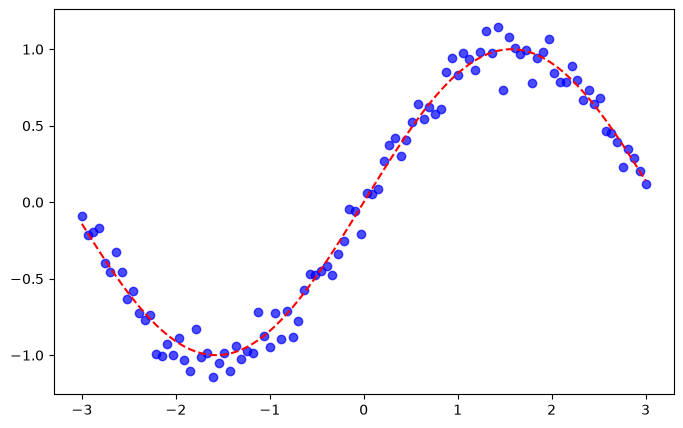

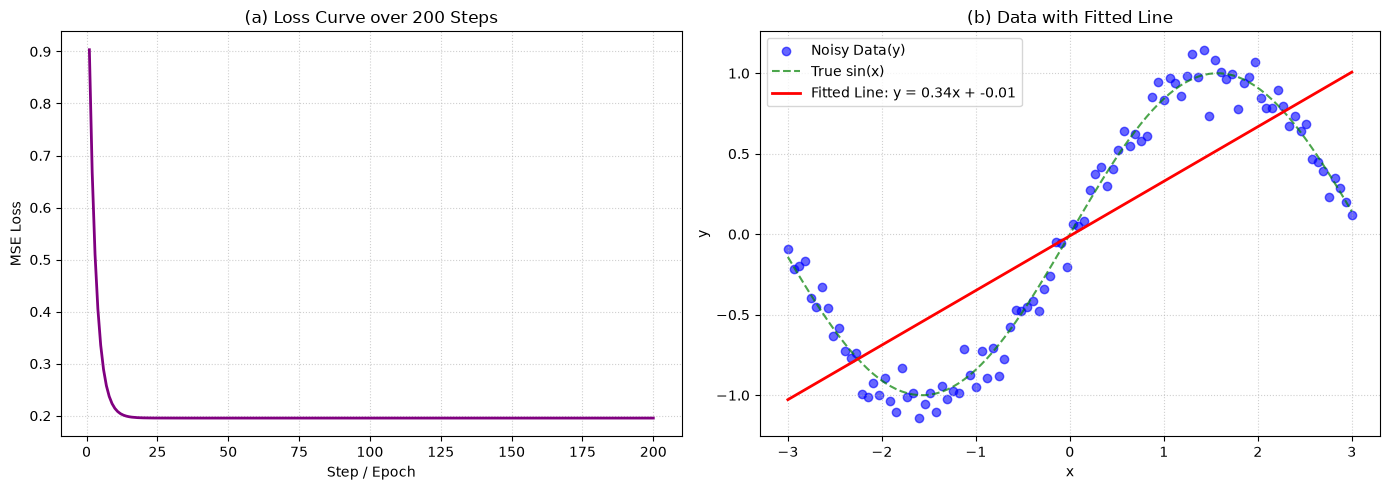

In [4]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

np.random.seed(42)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(loc = 0.0, scale = 0.1, size = x.shape)
y = np.sin(x) + noise

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="blue", alpha=0.7, label="Noisy Data (y)")
plt.plot(x, np.sin(x), color="red", linestyle="--", label="True sin(x)")



# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1


# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   Record the loss at every step.
lr = 0.03
epochs = 200

losshistory = [] #record the loss history

for step in range (epochs):
    y_hat = w * x + b
    f = y_hat - y
    loss = np.mean(f**2)
    losshistory.append(loss)
    dw = np.mean(2*f*x)
    db = np.mean(2*f)
    w -= lr*dw
    b -= lr*db 


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Loss curve plot
axes[0].plot(range(1, len(losshistory) + 1), losshistory, color="purple", linewidth=2)
axes[0].set_title("(a) Loss Curve over 200 Steps")
axes[0].set_xlabel("Step / Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)

#data with fitted line
axes[1].scatter(x, y, color='blue', alpha=0.6, label='Noisy Data(y)')
axes[1].plot(
    x, np.sin(x), color="green", linestyle="--", alpha=0.7, label="True sin(x)"
)
axes[1].plot(
    x,
    w * x + b,
    color="red",
    linewidth=2,
    label=f"Fitted Line: y = {w:.2f}x + {b:.2f}",
)
axes[1].set_title("(b) Data with Fitted Line")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

Part 1.2 — Hidden layers and activations: why depth helps

z1 shape: (100, 8)
h shape: (100, 8)
y_hat shape: (100, 1)
Loss: 4.227365639006744


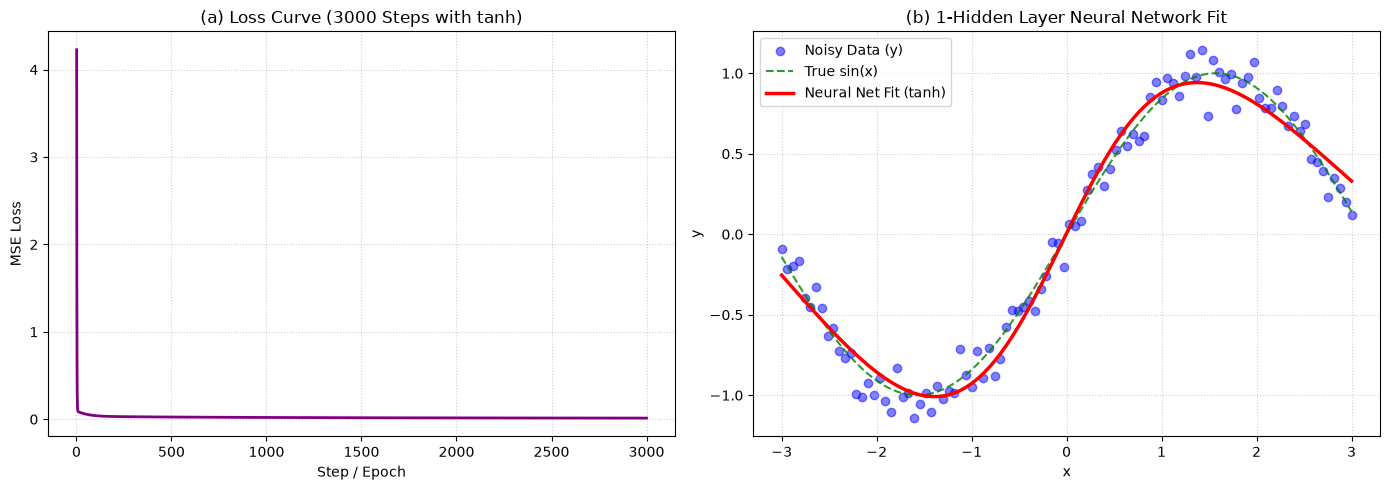

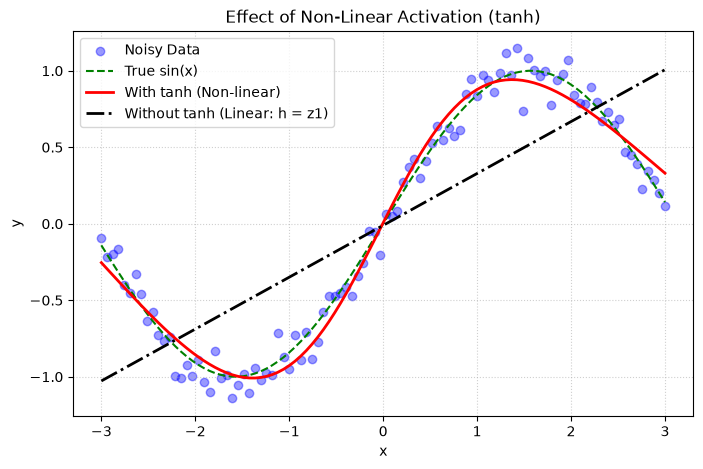

In [5]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5



# TODO: Forward pass (keep the intermediate values — you need them for backprop):
# Ensure x and y have 2D column shape (100, 1)
X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

z1 = X @ W1 + b1 
h = np.tanh(z1) 
y_hat = h @ W2 + b2
loss = np.mean((y_hat - Y) ** 2)

print("z1 shape:", z1.shape)
print("h shape:", h.shape)
print("y_hat shape:", y_hat.shape)
print("Loss:", loss)


# TODO: Backward pass (the chain rule, layer by layer):
N = len(Y)
d_yhat = 2 * (y_hat - Y) / N
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.05
steps = 3000

losshistory = []
for step in range(steps):
  # --- Forward Pass ---
  z1 = X @ W1 + b1  # (100, 8)
  h = np.tanh(z1)  # (100, 8)
  y_hat = h @ W2 + b2  # (100, 1)
  loss = np.mean((y_hat - Y) ** 2)
  losshistory.append(loss)
  
  # --- Backward Pass (Gradients) ---
  d_yhat = 2 * (y_hat - Y) / N  # (100, 1)
  dW2 = h.T @ d_yhat  # (8, 1)
  db2 = d_yhat.sum(axis=0)  # (1,)
  dh = d_yhat @ W2.T  # (100, 8)
  dz1 = dh * (1 - np.tanh(z1) ** 2)  # (100, 8)
  dW1 = X.T @ dz1  # (1, 8)
  db1 = dz1.sum(axis=0)  # (8,)
  
  # --- Parameter Updates ---
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2


# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# --- Plot (a): Loss Curve ---
axes[0].plot(range(1, len(losshistory) + 1), losshistory, color="purple", linewidth=2)
axes[0].set_title("(a) Loss Curve (3000 Steps with tanh)")
axes[0].set_xlabel("Step / Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)
# --- Plot (b): Final Fit over Data ---
axes[1].scatter(x, y, color="blue", alpha=0.5, label="Noisy Data (y)")
axes[1].plot(
    x, np.sin(x), color="green", linestyle="--", alpha=0.8, label="True sin(x)"
)
axes[1].plot(
  x,
  y_hat.flatten(),
  color="red",
  linewidth=2.5,
  label="Neural Net Fit (tanh)",
)
axes[1].set_title("(b) 1-Hidden Layer Neural Network Fit")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

#Re-running with tanh removed
# Re-initialise seed & parameters
np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

losses_linear = []

for step in range(3000):
  # Forward Pass WITHOUT tanh (Linear activation: h = z1)
  z1 = X @ W1 + b1
  h = z1  
  y_hat_linear = h @ W2 + b2

  loss = np.mean((y_hat_linear - Y) ** 2)
  losses_linear.append(loss)

  # Backward Pass
  d_yhat = 2 * (y_hat_linear - Y) / N
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh = d_yhat @ W2.T
  dz1 = dh * 1  

  dW1 = X.T @ dz1
  db1 = dz1.sum(axis=0)

  # Parameter Updates
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

# --- Plotting Comparison ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="blue", alpha=0.4, label="Noisy Data")
plt.plot(x, np.sin(x), color="green", linestyle="--", label="True sin(x)")
plt.plot(
  x, y_hat.flatten(), color="red", linewidth=2, label="With tanh (Non-linear)"
)
plt.plot(
  x,
  y_hat_linear.flatten(),
  color="black",
  linewidth=2,
  linestyle="-.",
  label="Without tanh (Linear: h = z1)",
)

plt.title("Effect of Non-Linear Activation (tanh)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


Part 1.3 — The learning rate: too cold, too hot, just right

lr = 0.001 | Start Loss: 4.5160 | Final Loss: 0.0718
lr = 0.050 | Start Loss: 4.5160 | Final Loss: 0.0110


c:\Users\USER\OneDrive - Ashesi University\Desktop\Ashesi stuff\AI\Code\intro-ai\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\USER\AppData\Local\Temp\ipykernel_25480\4079949119.py:20: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
C:\Users\USER\AppData\Local\Temp\ipykernel_25480\4079949119.py:27: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T  # (100, 8)
C:\Users\USER\AppData\Local\Temp\ipykernel_25480\4079949119.py:28: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)  # (100, 8)


lr = 1.000 | Start Loss: 4.5160 | Final Loss: nan


c:\Users\USER\OneDrive - Ashesi University\Desktop\Ashesi stuff\AI\Code\intro-ai\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


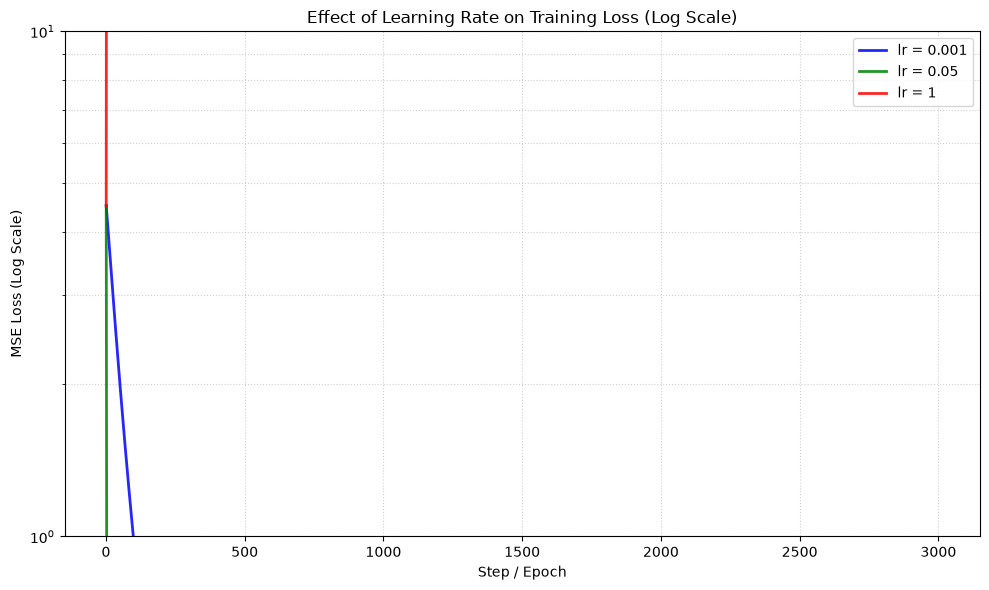

In [6]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(42)
    X = x.reshape(-1,1)
    Y = y.reshape(-1,1)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losshistory = []

    for step in range(steps):
        # --- Forward Pass ---
        z1 = X @ W1 + b1  # (100, 8)
        h = np.tanh(z1)  # (100, 8)
        y_hat = h @ W2 + b2  # (100, 1)
        loss = np.mean((y_hat - Y) ** 2)
        losshistory.append(loss)
        
        # --- Backward Pass (Gradients) ---
        d_yhat = 2 * (y_hat - Y) / N  # (100, 1)
        dW2 = h.T @ d_yhat  # (8, 1)
        db2 = d_yhat.sum(axis=0)  # (1,)
        dh = d_yhat @ W2.T  # (100, 8)
        dz1 = dh * (1 - np.tanh(z1) ** 2)  # (100, 8)
        dW1 = X.T @ dz1  # (1, 8)
        db1 = dz1.sum(axis=0)  # (8,)
        
        # --- Parameter Updates ---
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    
    return losshistory
        


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learningRates = [0.001, 0.05, 1]
results = {}

for lr in learningRates:
    loss_history = train_toy(lr, 3000)
    results[lr] = loss_history
    
    print(
        f"lr = {lr:5.3f} | Start Loss: {loss_history[0]:.4f} | Final Loss: {loss_history[-1]:.4f}"
    )


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(10, 6))
# Plot each learning rate curve from the results dictionary
colors = {0.001: "blue", 0.05: "green", 1.0: "red"}
for lr, losses in results.items():
    plt.plot(
        range(1, len(losses) + 1),
        losses,
        label=f"lr = {lr}",
        color=colors[lr],
        linewidth=2,
        alpha=0.85,
    )
# Use logarithmic scale for y-axis to highlight differences across orders of magnitude
plt.yscale("log")
plt.title("Effect of Learning Rate on Training Loss (Log Scale)")
plt.xlabel("Step / Epoch")
plt.ylabel("MSE Loss (Log Scale)")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)

In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
# Define OBESITY_URL (same as Lab 2)
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load the dataset into a pandas DataFrame
obesity = pd.read_csv(OBESITY_URL)

# Inspect dataset shape and first few rows
print(f"Obesity Dataset Shape: {obesity.shape}")
obesity.head()


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesityEncode = obesity.copy()

#binary encoding
binaryCols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binaryCols:
    obesityEncode[col] = obesityEncode[col].map({"yes": 1, "no": 0})

#gender enconding
obesityEncode["Gender"] = obesityEncode["Gender"].map(
    {"Female": 0, "Male": 1}
)

#Frequency encoding
freqCols = ["CAEC", "CALC"]
freqMapping = {
    "no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3 
}
for col in  freqCols:
    obesityEncode[col] = obesityEncode[col].map(freqMapping)

#One-Hot encoding (MTRANS)
obesityEncode = pd.get_dummies(
    obesityEncode, columns = ["MTRANS"], drop_first = True, dtype = int
)

obesityEncode.head()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obesityEncode["NObeyesdad_label"] = le.fit_transform(obesityEncode["NObeyesdad"])

obesityEncode.head()




# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# RANDOM_STATE = 42 (defined at the top of the notebook)
RANDOM_STATE = 42
X = obesityEncode.drop(columns=["NObeyesdad", "NObeyesdad_label"])
y = obesityEncode["NObeyesdad_label"]
# Step A: Split off 20% for Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Step B: Split remaining 80% into 75% Train (60% total) and 25% Val (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print(
    f"Splits - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}"
)




# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
import torch
from torch.utils.data import DataLoader, TensorDataset

# Features -> torch.float32, Target labels -> torch.long
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

#Wrap Tensors in TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch size = {BATCH_SIZE}:")
print(
    f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}"
)


2.2

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        # Sequential container for two hidden layers + output layer
        self.net = nn.Sequential(
            # Hidden Layer 1: input_dim -> 64
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            # Hidden Layer 2: 64 -> 32
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            # Output Layer: 32 -> 7 (raw logits, no Softmax)
            nn.Linear(hidden_sizes[1], n_classes),
        )
    def forward(self, x):
        return self.net(x)


# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X.shape[1]

model = FeedForwardNet(
    input_dim=input_dim, hidden_sizes=(64,32), n_classes=7
).to(DEVICE)

print("--- Model Architecture ---")
print(model)


# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

# Verify parameter count for Layer 1 by hand:
layer1_weights = input_dim * 64
layer1_biases = 64
layer1_hand_count = layer1_weights + layer1_biases     

2.3

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# 1. Configuration
epochs = 50
# Lists to track history across epochs
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
# Helper function to evaluate loss and accuracy over a DataLoader
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total_samples += len(yb)
    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy
# 2. Main Training Loop
print("Starting Training Loop (50 Epochs)...\n")
for epoch in range(1, epochs + 1):
    # --- 1. Training Phase ---
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()  # Reset accumulated gradients
        logits = model(xb)  # Forward pass
        loss = criterion(logits, yb)  # Compute CrossEntropy loss
        loss.backward()  # Backpropagation (computes dLoss/dW and dLoss/db)
        optimizer.step()  # Parameter update rule
    # --- 2. Evaluation Phase (Train and Validation) ---
    train_loss, train_acc = evaluate(model, train_loader, criterion, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    # --- 3. Record History ---
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    # Print summary every 5 epochs and at final epoch
    if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
        print(
            f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:6.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:6.2f}%"
        )


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
best_val_acc = 0.0
bestModelpath = "ffn_best.pt"

if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.